# SIOC 251 – Homework 3 Monte Carlo Scattering PartII

**Name:** Claire Liu   
**Date:** 5/18/26

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
def monte_carlo_scattering(n_photons, tau_star, omega=1.0, mu0=1.0, z_atm=1.0):
    dz_per_tau = z_atm / tau_star
    n_direct = 0
    n_diffuse = 0
    n_reflected = 0
    n_absorbed = 0

    for i in range(n_photons):
        # Initial direction: incoming at zenith angle theta0 = arccos(mu0)
        theta = np.arccos(mu0)  # zenith angle of propagation (downward)
        phi_dir = 0.0           # azimuthal angle (arbitrary for initial beam)

        # Propagation vector k = (cos(phi)*sin(theta), sin(phi)*sin(theta), -cos(theta))
        kx = np.cos(phi_dir) * np.sin(theta)
        ky = np.sin(phi_dir) * np.sin(theta)
        kz = -np.cos(theta)  # negative = downward

        z = z_atm
        n_scatters = 0
        alive = True

        while alive:
            delta_tau = -np.log(np.random.uniform())
            ds = delta_tau * dz_per_tau

            # Update position: only z matters in plane-parallel
            z_new = z + kz * ds

            if z_new >= z_atm:
                n_reflected += 1
                alive = False
            elif z_new <= 0:
                if n_scatters == 0:
                    n_direct += 1
                else:
                    n_diffuse += 1
                alive = False
            else:
                z = z_new

                if np.random.uniform() < omega:
                    n_scatters += 1

                    # Sample scattering angles
                    cos_Theta = 2 * np.random.uniform() - 1
                    sin_Theta = np.sqrt(1 - cos_Theta**2)
                    Phi = 2 * np.pi * np.random.uniform()

                    # Scattered direction in photon coordinates
                    kp_x = sin_Theta * np.cos(Phi)
                    kp_y = sin_Theta * np.sin(Phi)
                    kp_z = cos_Theta

                    # Build local coordinate system 
                    # z_p = k0 (incoming direction)
                    zp = np.array([kx, ky, kz])

                    # x_p: horizontal, perpendicular to z_p
                    kxy = np.sqrt(kx**2 + ky**2)
                    if kxy > 1e-8:
                        xp = np.array([-ky, kx, 0.0]) / kxy
                    else:
                        xp = np.array([1.0, 0.0, 0.0])

                    # y_p = z_p x x_p
                    yp = np.cross(zp, xp)

                    # Rotate to model coordinates 
                    k_new = kp_x * xp + kp_y * yp + kp_z * zp

                    # Normalize to prevent drift
                    k_new = k_new / np.linalg.norm(k_new)

                    kx, ky, kz = k_new
                else:
                    n_absorbed += 1
                    alive = False

    return {
        'direct_T': n_direct / n_photons,
        'diffuse_T': n_diffuse / n_photons,
        'total_T': (n_direct + n_diffuse) / n_photons,
        'albedo': n_reflected / n_photons,
        'absorptance': n_absorbed / n_photons,
    }

In [15]:
def monte_carlo_hg(n_photons, tau_star, omega=1.0, g=0.0, mu0=1.0, z_atm=1.0):
    dz_per_tau = z_atm / tau_star
    n_direct = 0
    n_diffuse = 0
    n_reflected = 0
    n_absorbed = 0

    for i in range(n_photons):
        theta = np.arccos(mu0)
        phi_dir = 0.0

        kx = np.cos(phi_dir) * np.sin(theta)
        ky = np.sin(phi_dir) * np.sin(theta)
        kz = -np.cos(theta)

        z = z_atm
        n_scatters = 0
        alive = True

        while alive:
            delta_tau = -np.log(np.random.uniform())
            ds = delta_tau * dz_per_tau
            z_new = z + kz * ds

            if z_new >= z_atm:
                n_reflected += 1
                alive = False
            elif z_new <= 0:
                if n_scatters == 0:
                    n_direct += 1
                else:
                    n_diffuse += 1
                alive = False
            else:
                z = z_new

                if np.random.uniform() < omega:
                    n_scatters += 1

                    # Henyey-Greenstein sampling
                    zeta = np.random.uniform()
                    if abs(g) < 1e-10:
                        cos_Theta = 2 * zeta - 1
                    else:
                        s = (1 - g**2) / (1 - g + 2 * g * zeta)
                        cos_Theta = (1 + g**2 - s**2) / (2 * g)
                    
                    # Clamp to [-1, 1] for numerical safety
                    cos_Theta = max(-1.0, min(1.0, cos_Theta))
                    
                    sin_Theta = np.sqrt(1 - cos_Theta**2)
                    Phi = 2 * np.pi * np.random.uniform()

                    kp_x = sin_Theta * np.cos(Phi)
                    kp_y = sin_Theta * np.sin(Phi)
                    kp_z = cos_Theta

                    zp = np.array([kx, ky, kz])
                    kxy = np.sqrt(kx**2 + ky**2)
                    if kxy > 1e-8:
                        xp = np.array([-ky, kx, 0.0]) / kxy
                    else:
                        xp = np.array([1.0, 0.0, 0.0])
                    yp = np.cross(zp, xp)

                    k_new = kp_x * xp + kp_y * yp + kp_z * zp
                    k_new = k_new / np.linalg.norm(k_new)
                    kx, ky, kz = k_new
                else:
                    n_absorbed += 1
                    alive = False

    return {
        'direct_T': n_direct / n_photons,
        'diffuse_T': n_diffuse / n_photons,
        'total_T': (n_direct + n_diffuse) / n_photons,
        'albedo': n_reflected / n_photons,
        'absorptance': n_absorbed / n_photons,
    }

### 6.2 Verifications

In [16]:
result = monte_carlo_hg(n_photons=100000, tau_star=0.5, omega=0, mu0=np.cos(0.78))
tau_star = 0.5
mu = np.cos(0.78)
print(f"MC transmittance: {result['total_T']:.4f}")
print(f"Beer's Law:       {np.exp(-tau_star / mu):.4f}")

MC transmittance: 0.4949
Beer's Law:       0.4949


In [21]:
for g in [0.0, 0.5, 0.85]:
    result = monte_carlo_hg(n_photons=100000, tau_star=2.0, omega=0.8, g=g, mu0=1.0)
    total = result['total_T'] + result['albedo'] + result['absorptance']
    print(f"g={g:.2f}  T={result['total_T']:.4f}  R={result['albedo']:.4f}  A={result['absorptance']:.4f}  Total={total:.4f}")

g=0.00  T=0.2862  R=0.2651  A=0.4487  Total=1.0000
g=0.50  T=0.4228  R=0.1362  A=0.4410  Total=1.0000
g=0.85  T=0.5906  R=0.0334  A=0.3760  Total=1.0000


In [24]:
#HG model with g=0 should match isotropic model
n_photons = 100000
tau_star = 2.0
omega = 0.8

r_iso = monte_carlo_scattering(n_photons, tau_star, omega=omega, mu0=1.0)
r_hg = monte_carlo_hg(n_photons, tau_star, omega=omega, g=0.0, mu0=1.0)

print("Isotropic model vs HG model (g=0):")
print(f"{'':15s} {'Isotropic':>10s} {'HG (g=0)':>10s}")
print(f"{'Direct T':15s} {r_iso['direct_T']:10.4f} {r_hg['direct_T']:10.4f}")
print(f"{'Diffuse T':15s} {r_iso['diffuse_T']:10.4f} {r_hg['diffuse_T']:10.4f}")
print(f"{'Albedo':15s} {r_iso['albedo']:10.4f} {r_hg['albedo']:10.4f}")
print(f"{'Absorptance':15s} {r_iso['absorptance']:10.4f} {r_hg['absorptance']:10.4f}")

Isotropic model vs HG model (g=0):
                 Isotropic   HG (g=0)
Direct T            0.1356     0.1341
Diffuse T           0.1518     0.1518
Albedo              0.2666     0.2656
Absorptance         0.4460     0.4484


### 6.3a

For a thin atmosphere (τ ≪ 1), most photons pass through without interacting.
From Beer's law, the probability of a photon passing through without interacting 
is $e^{-\tau^*}$, so the probability of interacting is $1 - e^{-\tau^*}$. 
For small $\tau^*$, Taylor expanding gives $e^{-\tau^*} \approx 1 - \tau^*$, so:

$$P(\text{interact}) \approx 1 - (1 - \tau^*) = \tau^*$$

Of those that interact, a fraction $\tilde{\omega}$ are scattered (the rest are absorbed).

For isotropic scattering (g = 0), the scattered photon goes in a random direction 
uniform over the sphere. Half go upward (into the backward hemisphere), half go 
downward. In the thin atmosphere limit, a scattered photon that goes upward will 
almost certainly escape out the top without further interaction.

Therefore:

$$\alpha \approx \tau^* \cdot \tilde{\omega} \cdot \frac{1}{2} = \frac{\tilde{\omega}\tau^*}{2}$$

The three factors are:
- $\tau^*$: probability of interacting (valid for $\tau^* \ll 1$)
- $\tilde{\omega}$: probability that the interaction is scattering
- $\frac{1}{2}$: probability that isotropic scattering sends the photon upward

# 6.3b

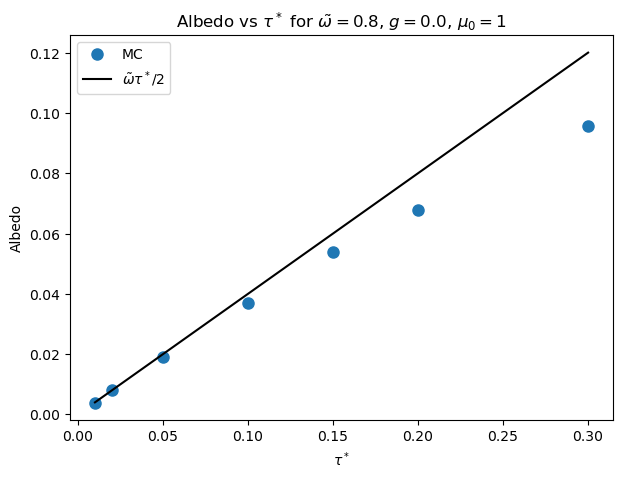

In [18]:
# 6.3b: Demonstrate alpha ≈ tau*omega/2 for thin atmosphere, g=0

n_photons = 100000
omega = 0.8
g = 0.0
taus = np.array([0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3])

mc_albedo = []
for tau in taus:
    r = monte_carlo_hg(n_photons, tau, omega=omega, g=g, mu0=1.0)
    mc_albedo.append(r['albedo'])
mc_albedo = np.array(mc_albedo)

analytic_albedo = omega * taus / 2

plt.figure(figsize=(7, 5))
plt.plot(taus, mc_albedo, 'o', label='MC', color='tab:blue', markersize=8)
plt.plot(taus, analytic_albedo, '-', label=r'$\tilde{\omega}\tau^*/2$', color='black')
plt.xlabel(r'$\tau^*$')
plt.ylabel('Albedo')
plt.title(rf'Albedo vs $\tau^*$ for $\tilde{{\omega}}={omega}$, $g={g}$, $\mu_0=1$')
plt.legend()
plt.savefig('figures/albedo_thin_atm.png', dpi=150, bbox_inches='tight')
plt.show()

The MC model gives similar values to analytical solutions when optical depth is small. 

# 6.3c

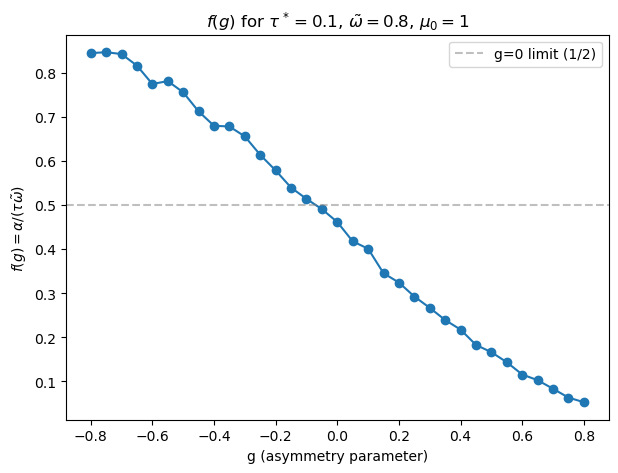

In [19]:
n_photons = 100000
tau = 0.1
omega = 0.8
gs = np.arange(-0.8, 0.85, 0.05)

f_g = []
for g_val in gs:
    r = monte_carlo_hg(n_photons, tau, omega=omega, g=g_val, mu0=1.0)
    f_g.append(r['albedo'] / (tau * omega))
f_g = np.array(f_g)

plt.figure(figsize=(7, 5))
plt.plot(gs, f_g, 'o-', color='tab:blue')
plt.xlabel('g (asymmetry parameter)')
plt.ylabel(r'$f(g) = \alpha / (\tau\tilde{\omega})$')
plt.title(rf'$f(g)$ for $\tau^*={tau}$, $\tilde{{\omega}}={omega}$, $\mu_0=1$')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='g=0 limit (1/2)')
plt.legend()
plt.savefig('figures/f_g_vs_g.png', dpi=150, bbox_inches='tight')
plt.show()

As g increases from negative to positive, albedo decreases when w and u are held constant.

## 6.3d

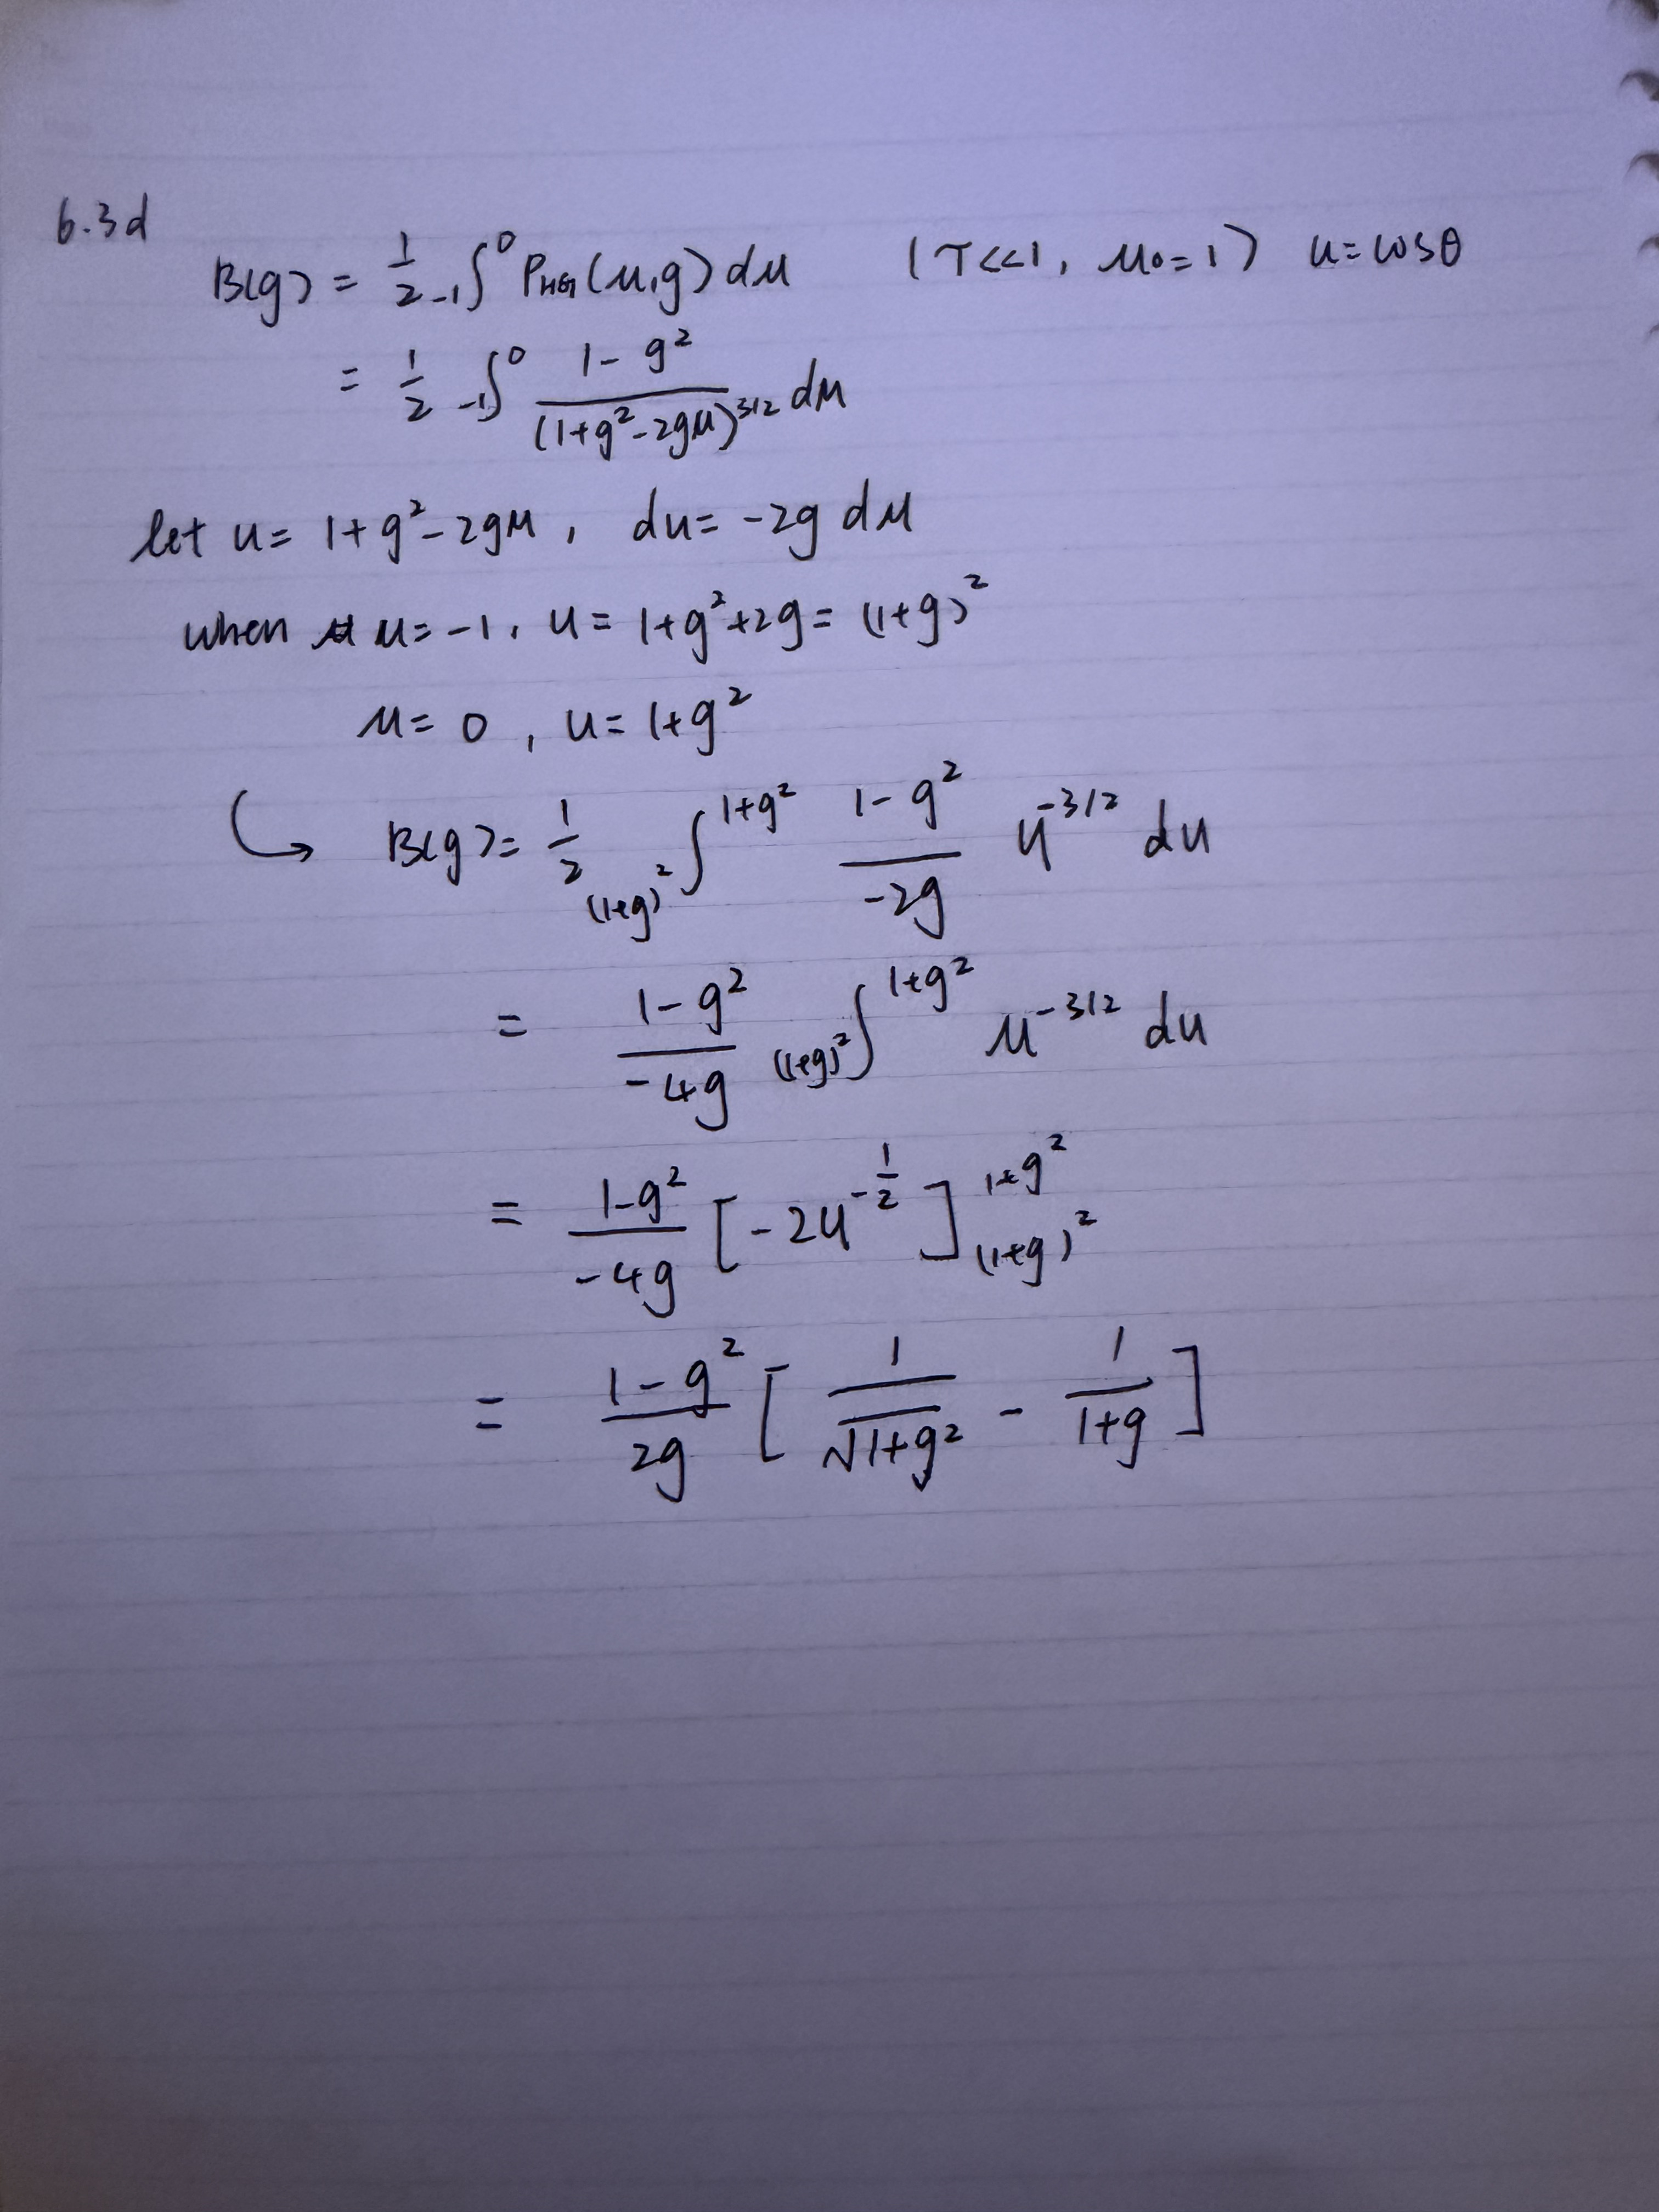

In [25]:
from IPython.display import Image
Image(filename='IMG_1263.jpg')

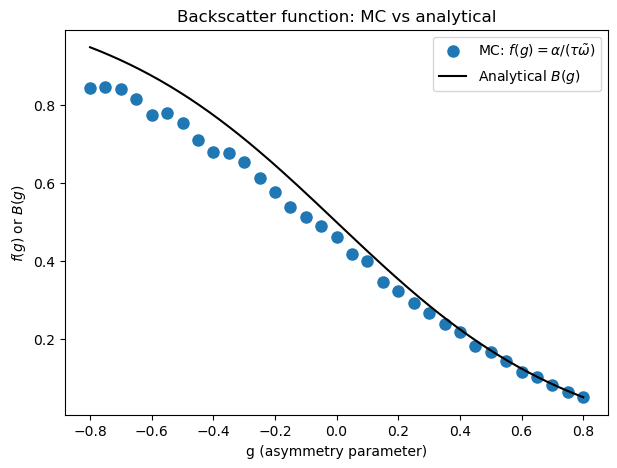

In [20]:
def backscatter_analytical(g):
    if abs(g) < 1e-10:
        return 0.5
    return (1 - g**2) / (2 * g) * (1 / np.sqrt(1 + g**2) - 1 / (1 + g))

gs_plot = np.linspace(-0.8, 0.8, 200)
B_analytical = np.array([backscatter_analytical(g_val) for g_val in gs_plot])

plt.figure(figsize=(7, 5))
plt.plot(gs, f_g, 'o', label=r'MC: $f(g) = \alpha/(\tau\tilde{\omega})$', color='tab:blue', markersize=8)
plt.plot(gs_plot, B_analytical, '-', label='Analytical $B(g)$', color='black')
plt.xlabel('g (asymmetry parameter)')
plt.ylabel(r'$f(g)$ or $B(g)$')
plt.title('Backscatter function: MC vs analytical')
plt.legend()
plt.savefig('figures/backscatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3e: How does forward scattering (g) affect the direct-to-diffuse ratio at the surface?

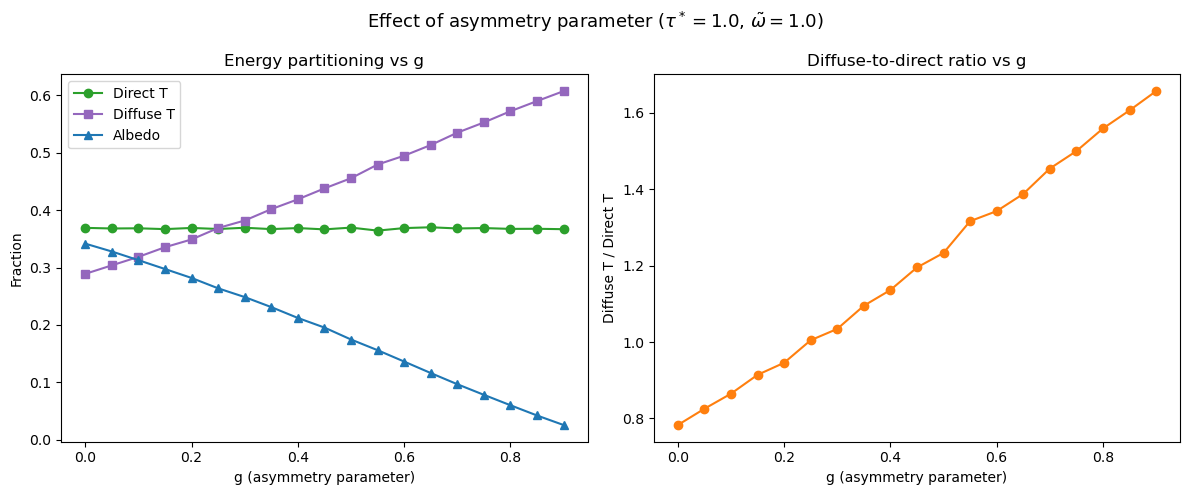

In [11]:
n_photons = 100000
tau = 1.0
omega = 1.0
gs = np.arange(0, 0.95, 0.05)

direct_T = []
diffuse_T = []
albedo = []

for g_val in gs:
    r = monte_carlo_hg(n_photons, tau, omega=omega, g=g_val, mu0=1.0)
    direct_T.append(r['direct_T'])
    diffuse_T.append(r['diffuse_T'])
    albedo.append(r['albedo'])

direct_T = np.array(direct_T)
diffuse_T = np.array(diffuse_T)
albedo = np.array(albedo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(gs, direct_T, 'o-', label='Direct T', color='tab:green')
axes[0].plot(gs, diffuse_T, 's-', label='Diffuse T', color='tab:purple')
axes[0].plot(gs, albedo, '^-', label='Albedo', color='tab:blue')
axes[0].set_xlabel('g (asymmetry parameter)')
axes[0].set_ylabel('Fraction')
axes[0].set_title('Energy partitioning vs g')
axes[0].legend()

axes[1].plot(gs, diffuse_T / (direct_T + 1e-10), 'o-', color='tab:orange')
axes[1].set_xlabel('g (asymmetry parameter)')
axes[1].set_ylabel('Diffuse T / Direct T')
axes[1].set_title('Diffuse-to-direct ratio vs g')

plt.suptitle(rf'Effect of asymmetry parameter ($\tau^*={tau}$, $\tilde{{\omega}}={omega}$)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/g_vs_energy_partitioning.png', dpi=150, bbox_inches='tight')
plt.show()

As g increases, albedo drops and diffuse transmittance increases, while direct transmittance stays the same. This makes sense because forward scattering basically redirects photons slightly off their original path but keeps them going downward, so they still reach the surface but count as diffuse instead of direct. The diffuse-to-direct ratio goes up with g for the same reason. This means that for something like cloud droplets (g ≈ 0.85), even though there's a lot of scattering happening, most of it just pushes light forward through the cloud rather than reflecting it back to space. 

# AI Usage
Tool used: Claude

How it was used: I used Claude to make the functions and the plots.

What I changed: I went over the code, modified the parameters for the plots and interpreted the plots to answer the questions.

How I verified the result: I verifed the results using Beer's law and calculated the total of transmittance, absorptance, and reflectance (=1). I've also compared the results of HG model when g=0 (isotropic scattering) to the model from part 1, and they should give close values.
